Using device: cpu
Observations Shape: (127, 64, 64, 3)
Actions Shape: (127,)
Generating VAE reconstructions...
Generating dream sequence...


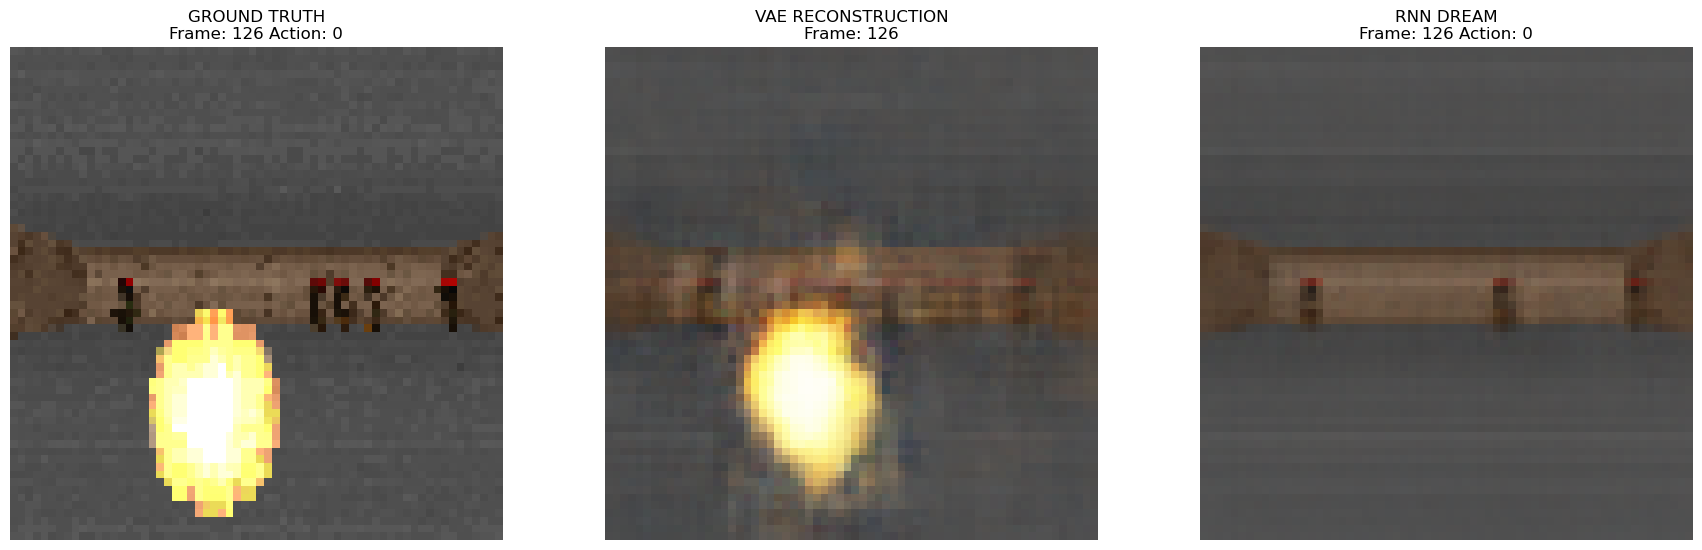

In [ ]:
import numpy as np
import torch
import argparse
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML
import sys
sys.path.append('..')
from modules.mdn_rnn import MDN_RNN
from modules.vae import VAE

def _sample_from_mdn(pi, mu, sigma, deterministic=True):
    """
    Sample a latent vector from the Mixture Density Network output.
    
    Args:
        pi (torch.Tensor): Mixture coefficients (K).
        mu (torch.Tensor): Mean vectors for each component (K, L).
        sigma (torch.Tensor): Std dev vectors for each component (K, L).
        deterministic (bool): If True, returns the mean of the most likely component.
                              Otherwise, samples from the distribution.
    
    Returns:
        torch.Tensor: The sampled latent vector (L).
    """
    if deterministic:
        # Select the component with the highest probability
        k = torch.argmax(pi)
        return mu[k]
    else:
        # Sample component index from the categorical distribution
        cat = torch.distributions.Categorical(probs=pi)
        k = cat.sample()
        
        # Select the corresponding mu and sigma
        mu_k = mu[k]
        sigma_k = sigma[k]
        
        # Sample from the chosen Gaussian
        eps = torch.randn_like(sigma_k)
        return mu_k + sigma_k * eps

class WorldModel:
    """
    A class that encapsulates the VAE, RNN, and the logic to generate sequences.
    """
    def __init__(self, vae_path, rnn_path, device='cpu'):
        self.device = device
        
        # Load VAE
        self.vae = VAE(latent_dim=32).to(self.device)
        self.vae.load_state_dict(torch.load(vae_path, map_location=device))
        self.vae.eval()
        
        # Load RNN
        self.rnn = MDN_RNN(
            latent_dim=32, 
            action_dim=1, 
            hidden_size=512, 
            n_gaussians=5, 
            num_layers=1
        ).to(self.device)
        self.rnn.load_state_dict(torch.load(rnn_path, map_location=device))
        self.rnn.eval()

    def reconstruct_sequence(self, observations):
        """Encodes and decodes a sequence of observations using the VAE."""
        with torch.no_grad():
            obs_tensor = torch.tensor(observations / 255.0, dtype=torch.float32).permute(0, 3, 1, 2).to(self.device)
            recon_x, _, _, _ = self.vae(obs_tensor)
            return recon_x.permute(0, 2, 3, 1).cpu().numpy()

    def generate_dream_sequence(self, initial_frame, actions, deterministic=True):
        """
        Generates a "dream" sequence using the RNN, starting from an initial frame.
        """
        num_frames = len(actions)
        dreamed_frames = []
        
        with torch.no_grad():
            # 1. Encode the initial frame to get the first latent vector z
            init_frame_tensor = torch.tensor(initial_frame / 255.0, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(self.device)
            current_z = self.vae.encode(init_frame_tensor).squeeze(0)
            
            # 2. Initialize RNN hidden state
            h0, c0 = self.rnn.initial_hidden(batch_size=1)
            h0.to(self.device); c0.to(self.device)

            # 3. Loop through actions to generate next frames
            for i in range(num_frames):
                action_tensor = torch.tensor(actions[i], dtype=torch.float32).unsqueeze(0).to(self.device)
                
                # Prepare RNN input: [current_z, current_action]
                rnn_input = torch.cat([current_z, action_tensor], dim=-1).unsqueeze(0).unsqueeze(0)
                
                # Predict the distribution of the next latent state
                pi, mu, sigma, hidden = self.rnn(rnn_input, (h0,c0))
                
                # Squeeze to remove batch/sequence dimensions
                pi, mu, sigma = pi.squeeze(), mu.squeeze(), sigma.squeeze()
                
                # Sample the next latent state from the MDN output
                z_next = _sample_from_mdn(pi, mu, sigma, deterministic)
                current_z = z_next
                
                # Decode the new latent state to get the dreamed frame
                dreamed_frame_tensor = self.vae.decoder(z_next.unsqueeze(0)).squeeze(0)
                dreamed_frame = dreamed_frame_tensor.permute(1, 2, 0).cpu().numpy()
                dreamed_frames.append(dreamed_frame)
                
        return np.array(dreamed_frames)

def create_comparison_animation(ground_truth, decoded_gt, dreamed_frames, actions, save_path=None):
    """
    Creates and optionally saves a side-by-side animation of the three sequences.
    """
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    
    def update_frame(frame):
        # Ground Truth
        ax1.clear()
        ax1.imshow(ground_truth[frame])
        ax1.set_title(f'GROUND TRUTH\nFrame: {frame} Action: {actions[frame]}')
        ax1.axis('off')

        # VAE Decoded GT
        ax2.clear()
        ax2.imshow(decoded_gt[frame])
        ax2.set_title(f'VAE RECONSTRUCTION\nFrame: {frame}')
        ax2.axis('off')

        # RNN Dream
        ax3.clear()
        # The first dreamed frame is the initial input
        ax3.imshow(dreamed_frames[frame])
        if frame == 0:
            ax3.set_title(f'RNN INITIAL INPUT')
        else:
            ax3.set_title(f'RNN DREAM\nFrame: {frame} Action: {actions[frame]}')
        ax3.axis('off')

    anim = FuncAnimation(fig, update_frame, frames=len(ground_truth), interval=100)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for suptitle
    
    if save_path:
        print(f"Saving animation to {save_path}...")
        anim.save(save_path, writer=PillowWriter(fps=10))
        print("Done.")
    
    return anim

def main(args):
    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() and not args.force_cpu else "cpu")
    print(f"Using device: {device}")

    # Load data
    try:
        rollout = np.load(args.data_path)
    except FileNotFoundError:
        print(f"Error: Data file not found at {args.data_path}")
        return

    observations = rollout['observations'][args.start_frame : args.start_frame + args.seq_length]
    actions = rollout['actions'][args.start_frame : args.start_frame + args.seq_length]
    print(f'Observations Shape: {observations.shape}')
    print(f'Actions Shape: {actions.shape}')

    # Initialize World Model
    world_model = WorldModel(args.vae_path, args.rnn_path, device)

    # 1. Generate VAE reconstructions of the ground truth sequence for comparison
    print("Generating VAE reconstructions...")
    decoded_gt = world_model.reconstruct_sequence(observations)

    # 2. Generate the "dream" sequence from the RNN
    print("Generating dream sequence...")
    # The dream starts from the first observation and uses the subsequent N-1 actions
    initial_frame = observations[0]
    actions_for_dream = actions[:-1]
    dreamed_generated_frames = world_model.generate_dream_sequence(initial_frame, actions_for_dream, deterministic=not args.stochastic)

    # The full dreamed sequence includes the initial frame
    dreamed_frames = np.concatenate(([initial_frame / 255.0], dreamed_generated_frames), axis=0)

    # 3. Create the animation
    anim = create_comparison_animation(
        ground_truth=observations,
        decoded_gt=decoded_gt,
        dreamed_frames=dreamed_frames,
        actions=actions, # Pass the full actions array for correct labeling
        save_path=args.save_path
    )
    
    # Display in a notebook environment
    display(HTML(anim.to_jshtml()))


if __name__ == '__main__':
    # parser = argparse.ArgumentParser(description="Generate and visualize dreams from a VAE-RNN World Model.")
    # parser.add_argument('--data_path', type=str, default='../data/vizdoom_val/rollout_00000.npz', help='Path to the rollout data file (.npz).')
    # parser.add_argument('--vae_path', type=str, default='../models/vizDoom/vae.lat32.e100.bs16.sample1000.17-07_epoch100.pt', help='Path to the trained VAE model.')
    # parser.add_argument('--rnn_path', type=str, default='../models/vizDoom/rnn.l32.h512.seq500.e100.bs128.latent32_vizdoom_2.5k.18-07.pt', help='Path to the trained MDN-RNN model.')
    # parser.add_argument('--start_frame', type=int, default=115, help='The starting frame index in the rollout.')
    # parser.add_argument('--seq_length', type=int, default=50, help='The length of the sequence to visualize.')
    # parser.add_argument('--save_path', type=str, default=None, help='Path to save the animation GIF. If None, it will not be saved.')
    # parser.add_argument('--stochastic', action='store_true', help='Use stochastic sampling for the dream sequence.')
    # parser.add_argument('--force_cpu', action='store_true', help='Force the use of CPU even if CUDA is available.')
    
    # In a notebook, you can't use argparse directly. Uncomment and modify this for notebook use.
    class Args:
        data_path = '../data/vizdoom_val/rollout_00000.npz'
        vae_path = '../models/vizDoom/vae.lat32.e100.bs16.sample1000.17-07_epoch100.pt'
        rnn_path = '../models/vizDoom/rnn.l32.h512.seq500.e100.bs128.latent32_vizdoom_2.5k.18-07.pt'
        start_frame = 0
        seq_length = 500
        save_path = None # path or None
        stochastic = True
        force_cpu = False
    args = Args()
    
    # For command-line execution:
    # args = parser.parse_args()

    main(args)